In [51]:
import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

**DEPRESSION - INCOME LEVEL (ACROSS STATES)**

In [101]:
# read in csv
df1 = pd.read_csv("Df_5states_DepressionALL_FACTORS.csv", usecols=['Measure','State','Value'])
# make filter for the income labels in the Measure column
incomes = ['Depression - Less Than $25,000','Depression - $25,000-$49,999','Depression - $50,000-$74,999','Depression - $75,000 or More']




# only get entries w/ income in measure
df_clean = df1[df1['Measure'].isin(incomes)] # only get the rows that have "incomes list" for the measure column

# reset measure columns rows names (change bin names ) --> make NEW COLUMN W NAME U WANT 

newNamelyst = []

 

for row in df1['Measure']:
    if (row == 'Depression - Less Than $25,000'):
          newNamelyst.append('>25k$')
    elif(row == 'Depression - $25,000-$49,999'):
          newNamelyst.append('25-50k$')
    elif(row == 'Depression - $50,000-$74,999'):
          newNamelyst.append('50-75k$')
    elif(row == 'Depression - $75,000 or More'):
          newNamelyst.append('75k$<')
df_clean['NewColumn_labels'] = newNamelyst






          




df_clean.head()



/var/folders/89/1xx8slwx0sz7bb2jd1vmzghh0000gn/T/ipykernel_49282/3013831783.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['NewColumn_labels'] = newNamelyst


,Measure,State,Value,NewColumn_labels
85,"Depression - $25,000-$49,999",HI,16.3,25-50k$
86,"Depression - $25,000-$49,999",IA,22.6,25-50k$
87,"Depression - $25,000-$49,999",MI,25.4,25-50k$
88,"Depression - $25,000-$49,999",ND,27.9,25-50k$
89,"Depression - $25,000-$49,999",WV,35.6,25-50k$


In [62]:
# goal - be able to assing the order i want 
# do the pivot table way 

In [102]:
# table where states are lines, x axis is income level, and y axis is value

pivot_df = df_clean.pivot(index = 'State', columns='NewColumn_labels' , values = 'Value')
# index - state --> make the rows of the table the 'State' column
# columns - measure --> income brackets are columns
# values - Value --> depression score for each state based on income level 
pivot_df


NewColumn_labels,25-50k$,50-75k$,75k$<,>25k$
State,,,,
HI,16.3,11.8,11.8,25.7
IA,22.6,16.5,14.1,31.3
MI,25.4,21.7,18.5,36.5
ND,27.9,19.4,16.2,39.9
WV,35.6,27.3,22.4,42.9


Text(0, 0.5, 'Depression Score')

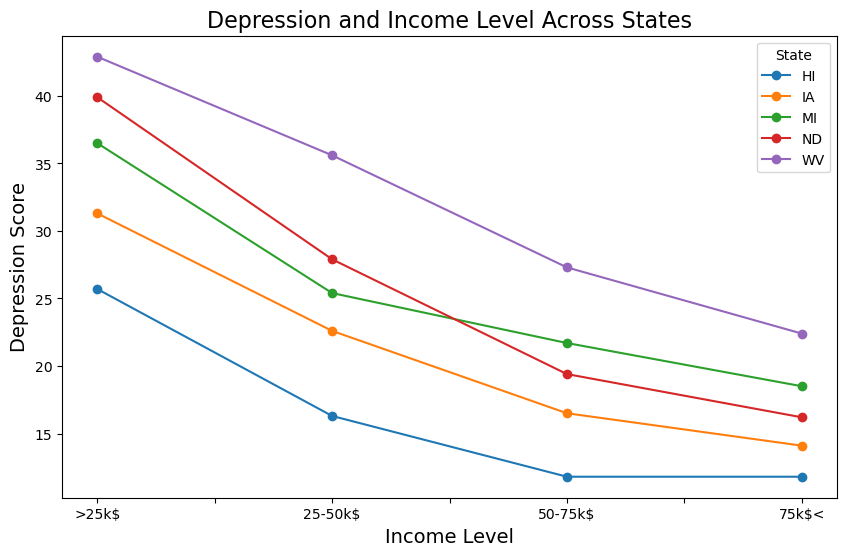

In [103]:
# Plot the pivot table as a line chart
new_column_order = ['>25k$', '25-50k$', '50-75k$', '75k$<']
 
# Reorder the columns

pivot_table_reordered = pivot_df.reindex(columns=new_column_order) # reindex - changes order of columns

#Transpose the pivot table
transposed_pivot = pivot_table_reordered.T # switches axis 

ax = transposed_pivot.plot(kind='line', figsize=(10, 6), marker='o')

#custom_xticklabels = ['>25k$', '25-50k$', '50-75k$', '$75<']
#ax.xticks(labels = custom_xticklabels)
ax.set_title("Depression and Income Level Across States",fontsize=16)
ax.set_xlabel("Income Level",fontsize=14)
ax.set_ylabel("Depression Score",fontsize=14)

In [74]:
transposed_pivot 

State,HI,IA,MI,ND,WV
Measure,,,,,
"Depression - Less Than $25,000",25.7,31.3,36.5,39.9,42.9
"Depression - $25,000-$49,999",16.3,22.6,25.4,27.9,35.6
"Depression - $50,000-$74,999",11.8,16.5,21.7,19.4,27.3
"Depression - $75,000 or More",11.8,14.1,18.5,16.2,22.4


Text(0, 0.5, 'Depression Score')

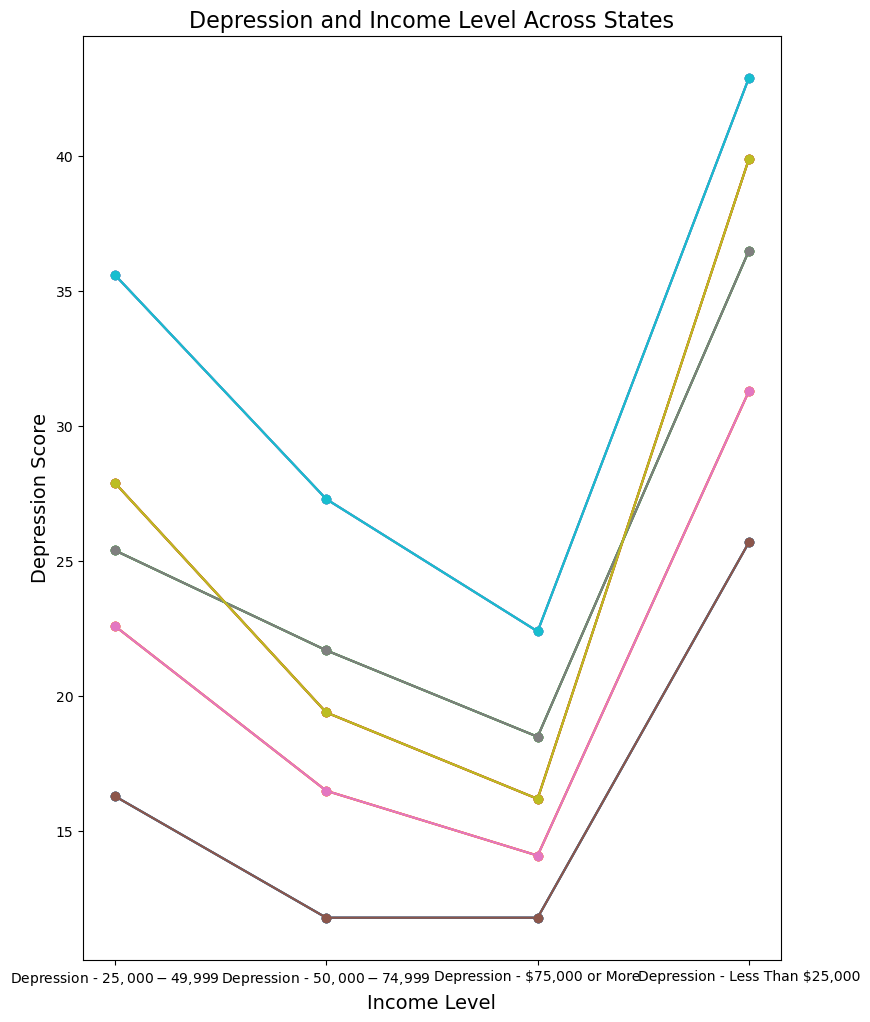

In [65]:
# old dont do this 


f, ax = plt.subplots(1,1, figsize=(9,12)) # create figure and axis 
for state in df_clean['State'].unique(): # iterate thru distinct state 
    # for each state's rows
    state_line = df_clean[df_clean['State'] == state] # get rows of that state 

    # plot line on axis for the state where measure is the x-axis (income) and value(depression scores) are y- axis 
    # marker = o - circle markers 
    # label = state --> makes the state the legend for the line 
    ax.plot(state_line['Measure'],state_line['Value'],marker='o',label=state)

ax.set_title("Depression and Income Level Across States",fontsize=16)
ax.set_xlabel("Income Level",fontsize=14)
ax.set_ylabel("Depression Score",fontsize=14)